Matplotlib is building the font cache; this may take a moment.


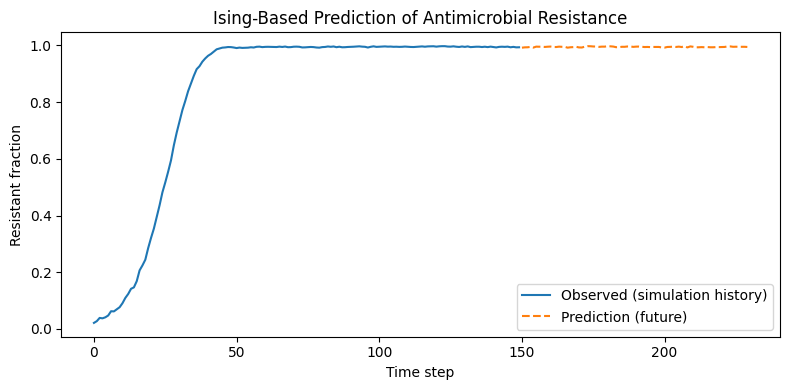

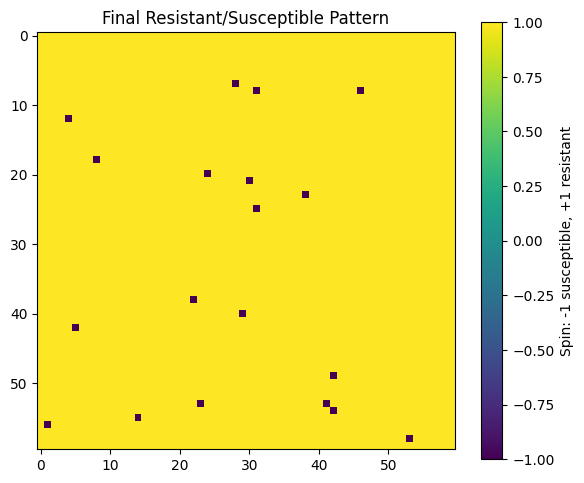

In [6]:
import numpy as np
import matplotlib.pyplot as plt

class IsingAMR:
    """
    Ising Model for Antimicrobial Resistance (AMR)
    ------------------------------------------------
    Spins:
        +1 -> Resistant (R)
        -1 -> Susceptible (S)

    Parameters:
        J  : interaction strength (neighbor influence / horizontal gene transfer effect)
        T  : temperature (stochasticity/randomness)
        H  : antibiotic pressure (external field favors resistance if H>0)
        mu : mutation probability (random flip)
    """
    def __init__(self, L=50, J=1.0, T=2.0, H=0.5, mu=0.001, seed=42):
        self.L = L
        self.J = J
        self.T = T
        self.H = H
        self.mu = mu
        self.rng = np.random.default_rng(seed)

        # Initialize lattice with mostly susceptible bacteria (-1)
        self.spins = -np.ones((L, L), dtype=int)
        # Seed some resistant bacteria
        num_seed = max(1, (L * L) // 50)  # ~2%
        idx = self.rng.choice(L * L, size=num_seed, replace=False)
        self.spins.flat[idx] = 1

    def _neighbors_sum(self, i, j):
        """Periodic boundary conditions"""
        L = self.L
        s = self.spins
        return (
            s[(i - 1) % L, j] +
            s[(i + 1) % L, j] +
            s[i, (j - 1) % L] +
            s[i, (j + 1) % L]
        )

    def _delta_energy(self, i, j):
        """
        Energy function:
            E = -J * sum_{<ij>} s_i s_j - H * sum_i s_i
        Flip spin at (i,j):
            ΔE = 2 * s_ij * (J * sum_neighbors + H)
        """
        sij = self.spins[i, j]
        neighbor_sum = self._neighbors_sum(i, j)
        return 2.0 * sij * (self.J * neighbor_sum + self.H)

    def metropolis_step(self):
        """One Monte Carlo sweep (L*L updates)"""
        L = self.L
        for _ in range(L * L):
            i = self.rng.integers(0, L)
            j = self.rng.integers(0, L)

            # Mutation: random flip
            if self.rng.random() < self.mu:
                self.spins[i, j] *= -1
                continue

            dE = self._delta_energy(i, j)

            # Metropolis acceptance probability
            if dE <= 0:
                self.spins[i, j] *= -1
            else:
                p = np.exp(-dE / self.T)
                if self.rng.random() < p:
                    self.spins[i, j] *= -1

    def resistant_fraction(self):
        """fraction of +1 spins"""
        return np.mean(self.spins == 1)

    def simulate(self, steps=200, burn_in=20, track=True):
        """
        Simulate AMR spread over time.
        Returns:
            fractions: resistant fraction per step
        """
        fractions = []

        for t in range(steps):
            self.metropolis_step()
            if track:
                fractions.append(self.resistant_fraction())

        return np.array(fractions)

    def predict_amr(self, future_steps=100, history_steps=150):
        """
        Run model and produce a simple AMR prediction curve.
        """
        frac = self.simulate(steps=history_steps + future_steps)

        history = frac[:history_steps]
        future = frac[history_steps:]

        return history, future

    def plot_state(self, title="Ising-AMR Lattice"):
        plt.figure(figsize=(6, 5))
        plt.imshow(self.spins, interpolation="nearest")
        plt.colorbar(label="Spin: -1 susceptible, +1 resistant")
        plt.title(title)
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    # ---- SETTINGS ----
    model = IsingAMR(
        L=60,     # lattice size
        J=1.2,    # neighbor influence
        T=1.8,    # randomness
        H=0.7,    # antibiotic pressure (high -> more resistance)
        mu=0.002  # mutation rate
    )

    history, future = model.predict_amr(future_steps=80, history_steps=150)

    # ---- Plot AMR Prediction ----
    plt.figure(figsize=(8, 4))
    plt.plot(history, label="Observed (simulation history)")
    plt.plot(range(len(history), len(history) + len(future)), future,
             label="Prediction (future)", linestyle="--")
    plt.xlabel("Time step")
    plt.ylabel("Resistant fraction")
    plt.title("Ising-Based Prediction of Antimicrobial Resistance")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot final lattice state
    model.plot_state("Final Resistant/Susceptible Pattern")


In [7]:
pip install pandas

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.9 MB 5.8 MB/s eta 0:00:02
   -------------------------------- ------- 8.1/9.9 MB 15.4 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 14.1 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


Filtered data points: 137
Observed Resistant fraction (Cefovecin): 0.2409
Using lattice size: 11x11 = 121 samples for Ising simulation

--- Calibrated Field (Antibiotic Pressure) ---
Best H: 0.10000000000000009
Simulated Resistant fraction: 0.0266
Absolute error: 0.2143


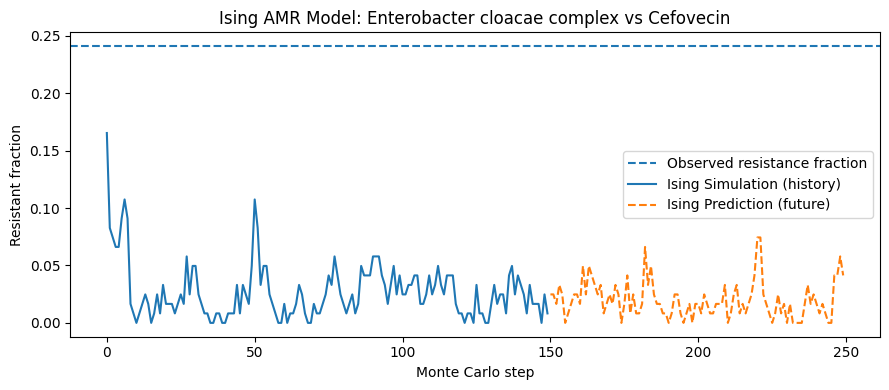

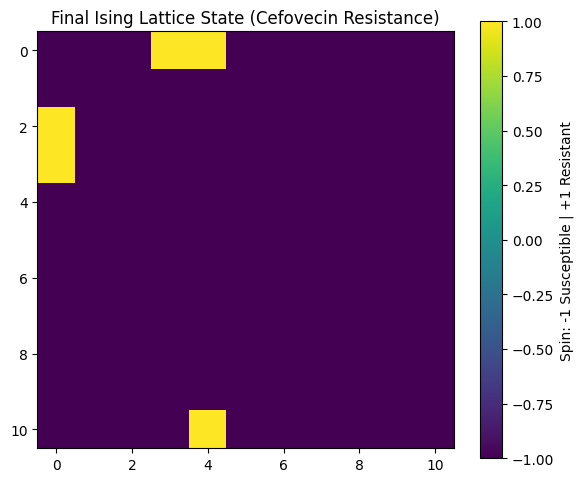

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# 1) Load dataset
# -------------------------------
FILE_PATH = r"C:\Users\msu-wone\Downloads\AMR_merged_all_samples_ordered.xlsx"

df = pd.read_excel(FILE_PATH)

# Filter organism + antibiotic column
org = "Enterobacter cloacae complex"
drug = "Cefovecin"

sub = df.loc[df["Bacteria"] == org, ["Sample_ID", drug]].copy()

# -------------------------------
# 2) Encode S/R/I to Ising spins
# -------------------------------
# Standard: R = +1, S = -1
# For "I" you can choose:
#   Option A: treat I as susceptible  -> -1
#   Option B: treat I as resistant    -> +1
#   Option C: ignore I                -> drop
I_MODE = "ignore"     # choose: "ignore", "susceptible", "resistant"

def encode_to_spin(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().upper()
    if x == "R":
        return 1
    if x == "S":
        return -1
    if x == "I":
        if I_MODE == "susceptible":
            return -1
        elif I_MODE == "resistant":
            return 1
        elif I_MODE == "ignore":
            return np.nan
    return np.nan

sub["spin"] = sub[drug].apply(encode_to_spin)
sub = sub.dropna(subset=["spin"]).copy()
sub["spin"] = sub["spin"].astype(int)

observed_spins = sub["spin"].to_numpy()
obs_resistant_frac = np.mean(observed_spins == 1)

print("Filtered data points:", len(observed_spins))
print("Observed Resistant fraction (Cefovecin):", round(obs_resistant_frac, 4))

# -------------------------------
# 3) Build Ising lattice from observed spins
# -------------------------------
# We'll reshape spins into an approximately square lattice for spatial Ising modeling.
N = len(observed_spins)
L = int(np.floor(np.sqrt(N)))
N_use = L * L

spins0 = observed_spins[:N_use].reshape(L, L)

print(f"Using lattice size: {L}x{L} = {N_use} samples for Ising simulation")

# -------------------------------
# 4) Ising Model (Metropolis)
# -------------------------------
def neighbors_sum(S, i, j):
    L = S.shape[0]
    return (S[(i-1) % L, j] + S[(i+1) % L, j] + S[i, (j-1) % L] + S[i, (j+1) % L])

def metropolis_sweep(S, J, T, H, rng):
    L = S.shape[0]
    for _ in range(L * L):
        i = rng.integers(0, L)
        j = rng.integers(0, L)

        sij = S[i, j]
        nb = neighbors_sum(S, i, j)

        # ΔE = 2*s*(J*sum_neighbors + H)
        dE = 2.0 * sij * (J * nb + H)

        if dE <= 0:
            S[i, j] *= -1
        else:
            if rng.random() < np.exp(-dE / T):
                S[i, j] *= -1
    return S

def resistant_fraction(S):
    return np.mean(S == 1)

# -------------------------------
# 5) Calibrate antibiotic pressure H
# -------------------------------
# We tune H so the simulated resistant fraction matches the observed fraction.
def simulate_fraction_for_H(H, J=1.0, T=1.8, burn=50, sweeps=120, seed=1):
    rng = np.random.default_rng(seed)
    S = spins0.copy()

    # burn in
    for _ in range(burn):
        S = metropolis_sweep(S, J, T, H, rng)

    fracs = []
    for _ in range(sweeps):
        S = metropolis_sweep(S, J, T, H, rng)
        fracs.append(resistant_fraction(S))

    return float(np.mean(fracs))

def calibrate_H(target_frac, H_values, J=1.0, T=1.8):
    best_H, best_err, best_sim = None, 1e9, None
    for H in H_values:
        sim_frac = simulate_fraction_for_H(H, J=J, T=T)
        err = abs(sim_frac - target_frac)
        if err < best_err:
            best_err = err
            best_H = H
            best_sim = sim_frac
    return best_H, best_sim, best_err

# grid search H
H_grid = np.linspace(-2.0, 2.0, 41)
J = 1.0
T = 1.8

best_H, sim_frac, err = calibrate_H(obs_resistant_frac, H_grid, J=J, T=T)

print("\n--- Calibrated Field (Antibiotic Pressure) ---")
print("Best H:", best_H)
print("Simulated Resistant fraction:", round(sim_frac, 4))
print("Absolute error:", round(err, 4))

# -------------------------------
# 6) Prediction Simulation
# -------------------------------
rng = np.random.default_rng(123)
S = spins0.copy()

burn_in = 50
total_steps = 250

fractions = []

for t in range(total_steps):
    S = metropolis_sweep(S, J=J, T=T, H=best_H, rng=rng)
    fractions.append(resistant_fraction(S))

fractions = np.array(fractions)

# split "history" and "prediction"
history_len = 150
history = fractions[:history_len]
future = fractions[history_len:]

# -------------------------------
# 7) Plots
# -------------------------------
plt.figure(figsize=(9, 4))
plt.axhline(obs_resistant_frac, linestyle="--", label="Observed resistance fraction")
plt.plot(history, label="Ising Simulation (history)")
plt.plot(range(history_len, history_len + len(future)), future, linestyle="--", label="Ising Prediction (future)")
plt.xlabel("Monte Carlo step")
plt.ylabel("Resistant fraction")
plt.title(f"Ising AMR Model: {org} vs {drug}")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(S, interpolation="nearest")
plt.colorbar(label="Spin: -1 Susceptible | +1 Resistant")
plt.title("Final Ising Lattice State (Cefovecin Resistance)")
plt.tight_layout()
plt.show()
